<a href="https://colab.research.google.com/github/Mangharam/Machine-Learning-Projects/blob/main/HousePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [ ]:
house = pd.read_csv('/content/Cleaned_Data.csv')

In [ ]:
house.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
house.head()

,Address,Price,NoOfBedrooms,NoOfBathrooms,AreaSqYards
0,"Bahria Town Karachi, Karachi",4200000.0,1.0,1.0,60
1,"Bahria Town - Precinct 17, Bahria Town Karachi",5900000.0,2.0,2.0,161
2,"Bahria Paradise, Bahria Town Karachi",42000000.0,5.0,5.0,500
3,"Askari 5 - Sector J, Askari 5",37500000.0,3.0,3.0,300
4,"Bahria Town - Precinct 35, Bahria Sports City",21000000.0,4.0,4.0,350


In [ ]:
house.shape

(16849, 5)

In [ ]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16849 entries, 0 to 16848
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Address        16849 non-null  object 
 1   Price          16849 non-null  float64
 2   NoOfBedrooms   16849 non-null  float64
 3   NoOfBathrooms  16849 non-null  float64
 4   AreaSqYards    16849 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 658.3+ KB


In [ ]:
house.describe()

,Price,NoOfBedrooms,NoOfBathrooms,AreaSqYards
count,1.684900e+04,16849.000000,16849.00000,16849.000000
mean,3.914858e+07,3.599442,3.73856,238.193958
std,3.657066e+07,1.439704,1.46110,137.991019
min,7.000000e+05,1.000000,1.00000,33.000000
25%,1.350000e+07,3.000000,3.00000,122.000000
50%,2.600000e+07,3.000000,3.00000,200.000000
75%,5.800000e+07,5.000000,5.00000,311.000000
max,4.000000e+08,11.000000,10.00000,993.000000


In [ ]:
house.isnull().sum()

,0
Address,0
Price,0
NoOfBedrooms,0
NoOfBathrooms,0
AreaSqYards,0


In [ ]:
correlation = house.corr(numeric_only=True)

<Axes: >

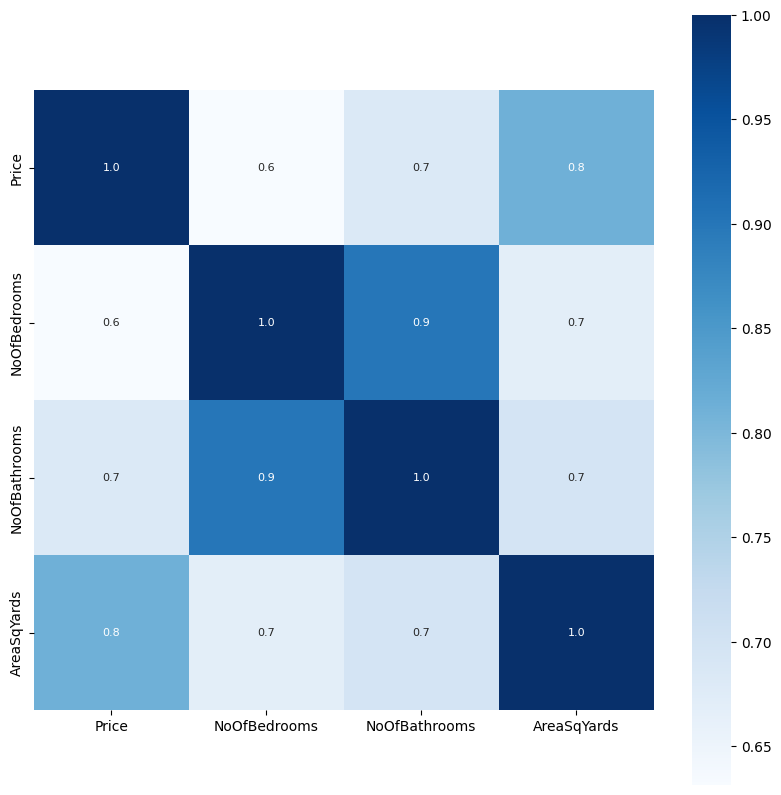

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8 }, cmap='Blues')

In [ ]:
X = house.drop('Price', axis=1)
y = house['Price']

In [ ]:
X

,Address,NoOfBedrooms,NoOfBathrooms,AreaSqYards
0,"Bahria Town Karachi, Karachi",1.0,1.0,60
1,"Bahria Town - Precinct 17, Bahria Town Karachi",2.0,2.0,161
2,"Bahria Paradise, Bahria Town Karachi",5.0,5.0,500
3,"Askari 5 - Sector J, Askari 5",3.0,3.0,300
4,"Bahria Town - Precinct 35, Bahria Sports City",4.0,4.0,350
...,...,...,...,...
16844,"Gulshan-e-Iqbal - Block 13/D-1, Gulshan-e-Iqbal",2.0,2.0,67
16845,"Emaar Pearl Towers, Emaar Crescent Bay",3.0,4.0,243
16846,"Federal B Area, Karachi",2.0,1.0,67
16847,"Gulshan-e-Iqbal - Block 13/C, Gulshan-e-Iqbal",4.0,4.0,240


In [ ]:
y

,Price
0,4200000.0
1,5900000.0
2,42000000.0
3,37500000.0
4,21000000.0
...,...
16844,4900000.0
16845,67500000.0
16846,4500000.0
16847,25000000.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(16849, 4) (13479, 4) (3370, 4)


In [ ]:
model = XGBRegressor()

In [ ]:
X_train_encoded = pd.get_dummies(X_train, columns=['Address'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['Address'], drop_first=True)

# Ensure that training and testing sets have the same columns after one-hot encoding
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

model.fit(X_train_encoded, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
training_data_prediction = (model.predict(X_train_encoded))

In [ ]:
print(training_data_prediction)

[34393464.   4141634.5 11320614.  ... 36423492.  94680304.  19900764. ]


In [ ]:
score_1 = metrics.r2_score(y_train, training_data_prediction)
score_2 = metrics.mean_absolute_error(y_train, training_data_prediction)
print('R squared error : ', score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.9204910913391049
Mean Absolute Error :  5614538.180187699


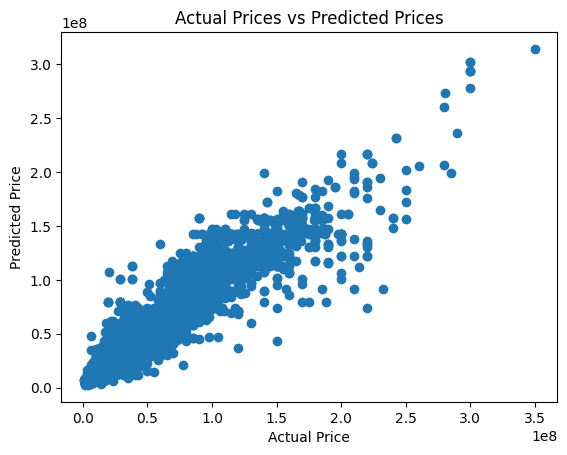

In [ ]:
plt.scatter(y_train, training_data_prediction)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Prices vs Predicted Prices')
plt.show()

In [ ]:
test_data_prediction = model.predict(X_test_encoded)

In [ ]:
score_1 = metrics.r2_score(y_test, test_data_prediction)
score_2 = metrics.mean_absolute_error(y_test, test_data_prediction)
print('R squared error : ', score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.8775181736309404
Mean Absolute Error :  6235346.837091988
